In [1]:
# System
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("../..")

In [2]:
# Setup
from importlib import import_module
from pathlib import Path
from time import time
from typing import cast

import numpy as np
import pandas as pd
from keras import ops
from src.callbacks import ImportanceUpdate
from src.models import LearnableCutFlowModel, LearnableCutFlowSequentialModel
from src.utils import (
    load_model,
    plot_learned_cut,
    plot_learned_importance,
    print,
    tex_to_str,
)

In [3]:
# Parameters
# Dataset
dataset = "mock4"  # *
n_samples = 200000
seed = 42

# Model
model_builder = "LearnableCutFlowSequential"  # *
centers = [-2, -1.8, -1.4]  # *
n_epochs = 200
batch_size = 512

# Figure
features = [r"$x_1$", r"$x_9$", r"$x_{10}$"]  # *
bins = np.linspace(-10, 10, 101)

# Directory
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")

FIGURES_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset}")
load_data = getattr(module, "load_data")
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 3)
y_train.shape=(100000, 1)
x_test.shape=(100000, 3)
y_test.shape=(100000, 1)


In [5]:
# Model
ModelBuilder = getattr(import_module("src.models"), model_builder)
model = ModelBuilder(x_train.shape, centers, features=features, name="lcf_seq")
model = cast(LearnableCutFlowModel, model)
model.summary(print_fn=print)

model.adapt(x_train)
model.compile(optimizer="adam", loss="crossentropy")

start_time = time()
model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    callbacks=[ImportanceUpdate(model)],
    verbose=2,
)
training_time = time() - start_time
print(f"\n\nTraining completed in {training_time:.2f} seconds")

model.save(CHECKPOINTS_DIR / "model.keras")

Model: "lcf_seq"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 3)         │          7 │ inputs[0][0]      │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_importan… │ (None, 3)         │          3 │ normalization[0]… │
│ (LearnableImportan… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split (Split)       │ [(None, 1),       │          0 │ learnable_import… │
│                     │ (None, 1), (None, │            │   

In [6]:
# Checkpoint
checkpoint = load_model(CHECKPOINTS_DIR / "model.keras")
checkpoint = cast(LearnableCutFlowModel, checkpoint)

In [7]:
# Analysis: metrics
y_pred = checkpoint.predict(x_test, batch_size=batch_size, verbose=0)
y_true = y_test

tp = ops.sum((y_true == 1) & (y_pred == 1))
fp = ops.sum((y_true == 0) & (y_pred == 1))
tn = ops.sum((y_true == 0) & (y_pred == 0))
fn = ops.sum((y_true == 1) & (y_pred == 0))

accuracy = (tp + tn) / (tp + tn + fp + fn)  # type: ignore
precision = tp / (tp + fp)  # type: ignore
significance = tp / ops.sqrt(fp)  # type: ignore

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

True positives.......41894
False positives.......8040
Accuracy............0.8400
Precision...........0.8390
Significance......467.2226


In [8]:
# Analysis: check metrics via learned cuts
mask = ops.ones_like(x_test[:, 0], dtype="bool")
n_features = x_test.shape[1]
selection = checkpoint.importance.scores > checkpoint.importance.baseline  # type: ignore
for i, cut in enumerate(checkpoint.cuts):
    if not selection[i]:
        print(
            f"{cut.expression} is ignored "
            f"({cut.importance_score.value:.4f} < {checkpoint.importance.baseline:.4f})"
        )
        continue

    x_i = x_test[:, i]
    boundaries = cut.boundaries
    index = cut.index

    if cut.case == 1:
        mask_i = x_i < boundaries[index]
    elif cut.case == 2:
        mask_i = x_i > boundaries[index]
    elif cut.case == 3:
        mask_i = ops.logical_and(boundaries[0] < x_i, x_i < boundaries[1])
    else:
        mask_i = ops.logical_or(x_i < boundaries[0], boundaries[1] < x_i)

    mask = ops.logical_and(mask, mask_i)

y_pred_cut = ops.cast(mask, dtype="float32")
y_pred_cut = ops.reshape(y_pred_cut, y_test.shape)
tp = ops.sum((y_pred_cut == 1) & (y_test == 1))
fp = ops.sum((y_pred_cut == 1) & (y_test == 0))
tn = ops.sum((y_pred_cut == 0) & (y_test == 0))
fn = ops.sum((y_pred_cut == 0) & (y_test == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)  # type: ignore
precision = tp / (tp + fp)  # type: ignore
significance = tp / ops.sqrt(fp)  # type: ignore

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

True positives.......41894
False positives.......8040
Accuracy............0.8400
Precision...........0.8390
Significance......467.2226


In [9]:
# Analysis: learned cuts
for cut in checkpoint.cuts:
    print(cut.expression)

$x_1$ < 0.0170
$x_9$ < 2.2908
$x_{10}$ < 2.7283


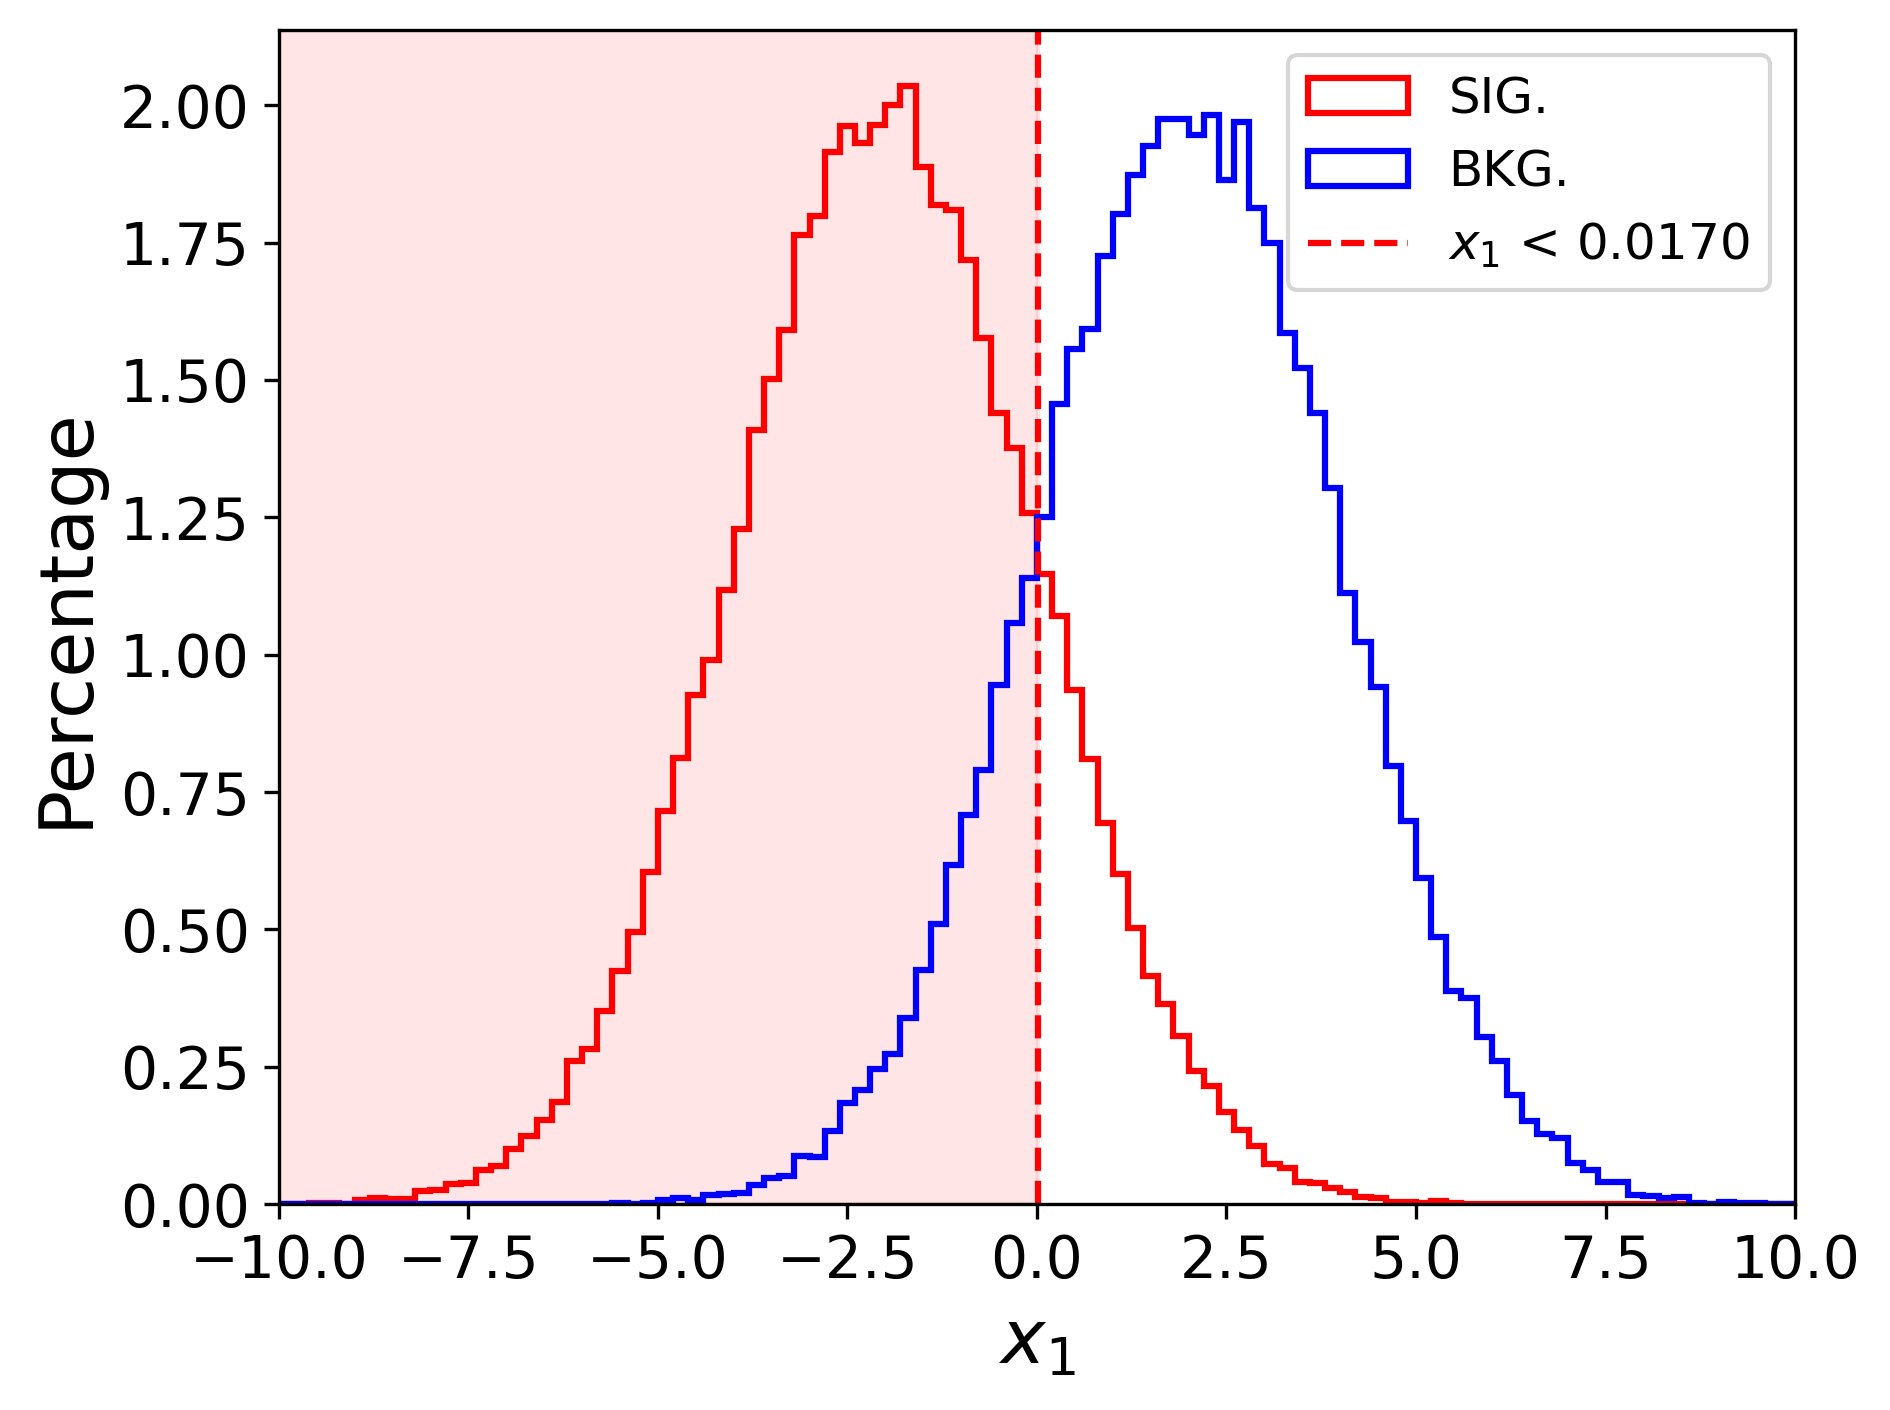

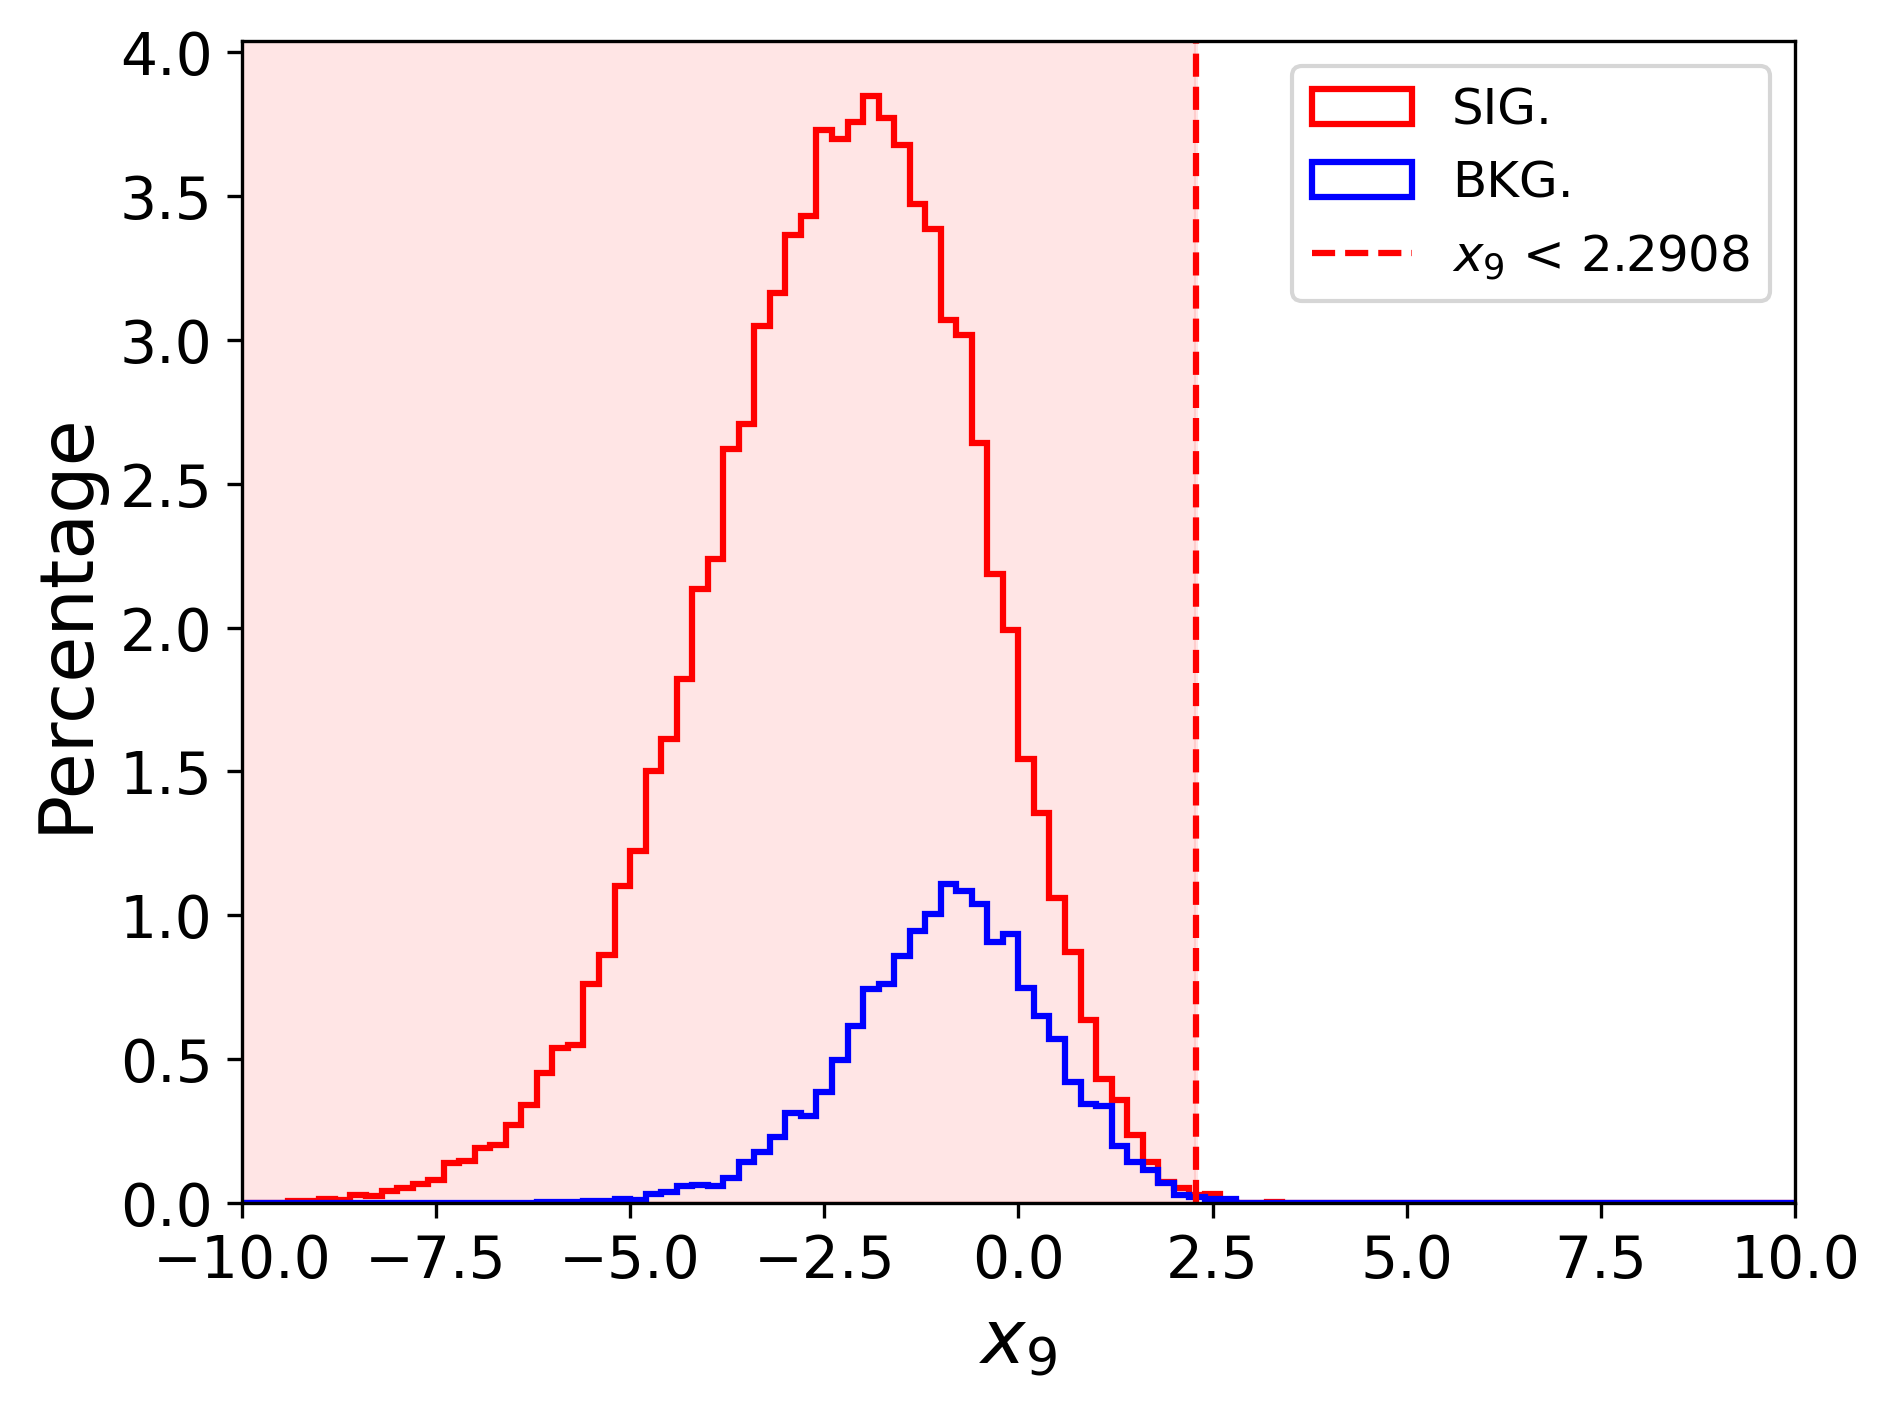

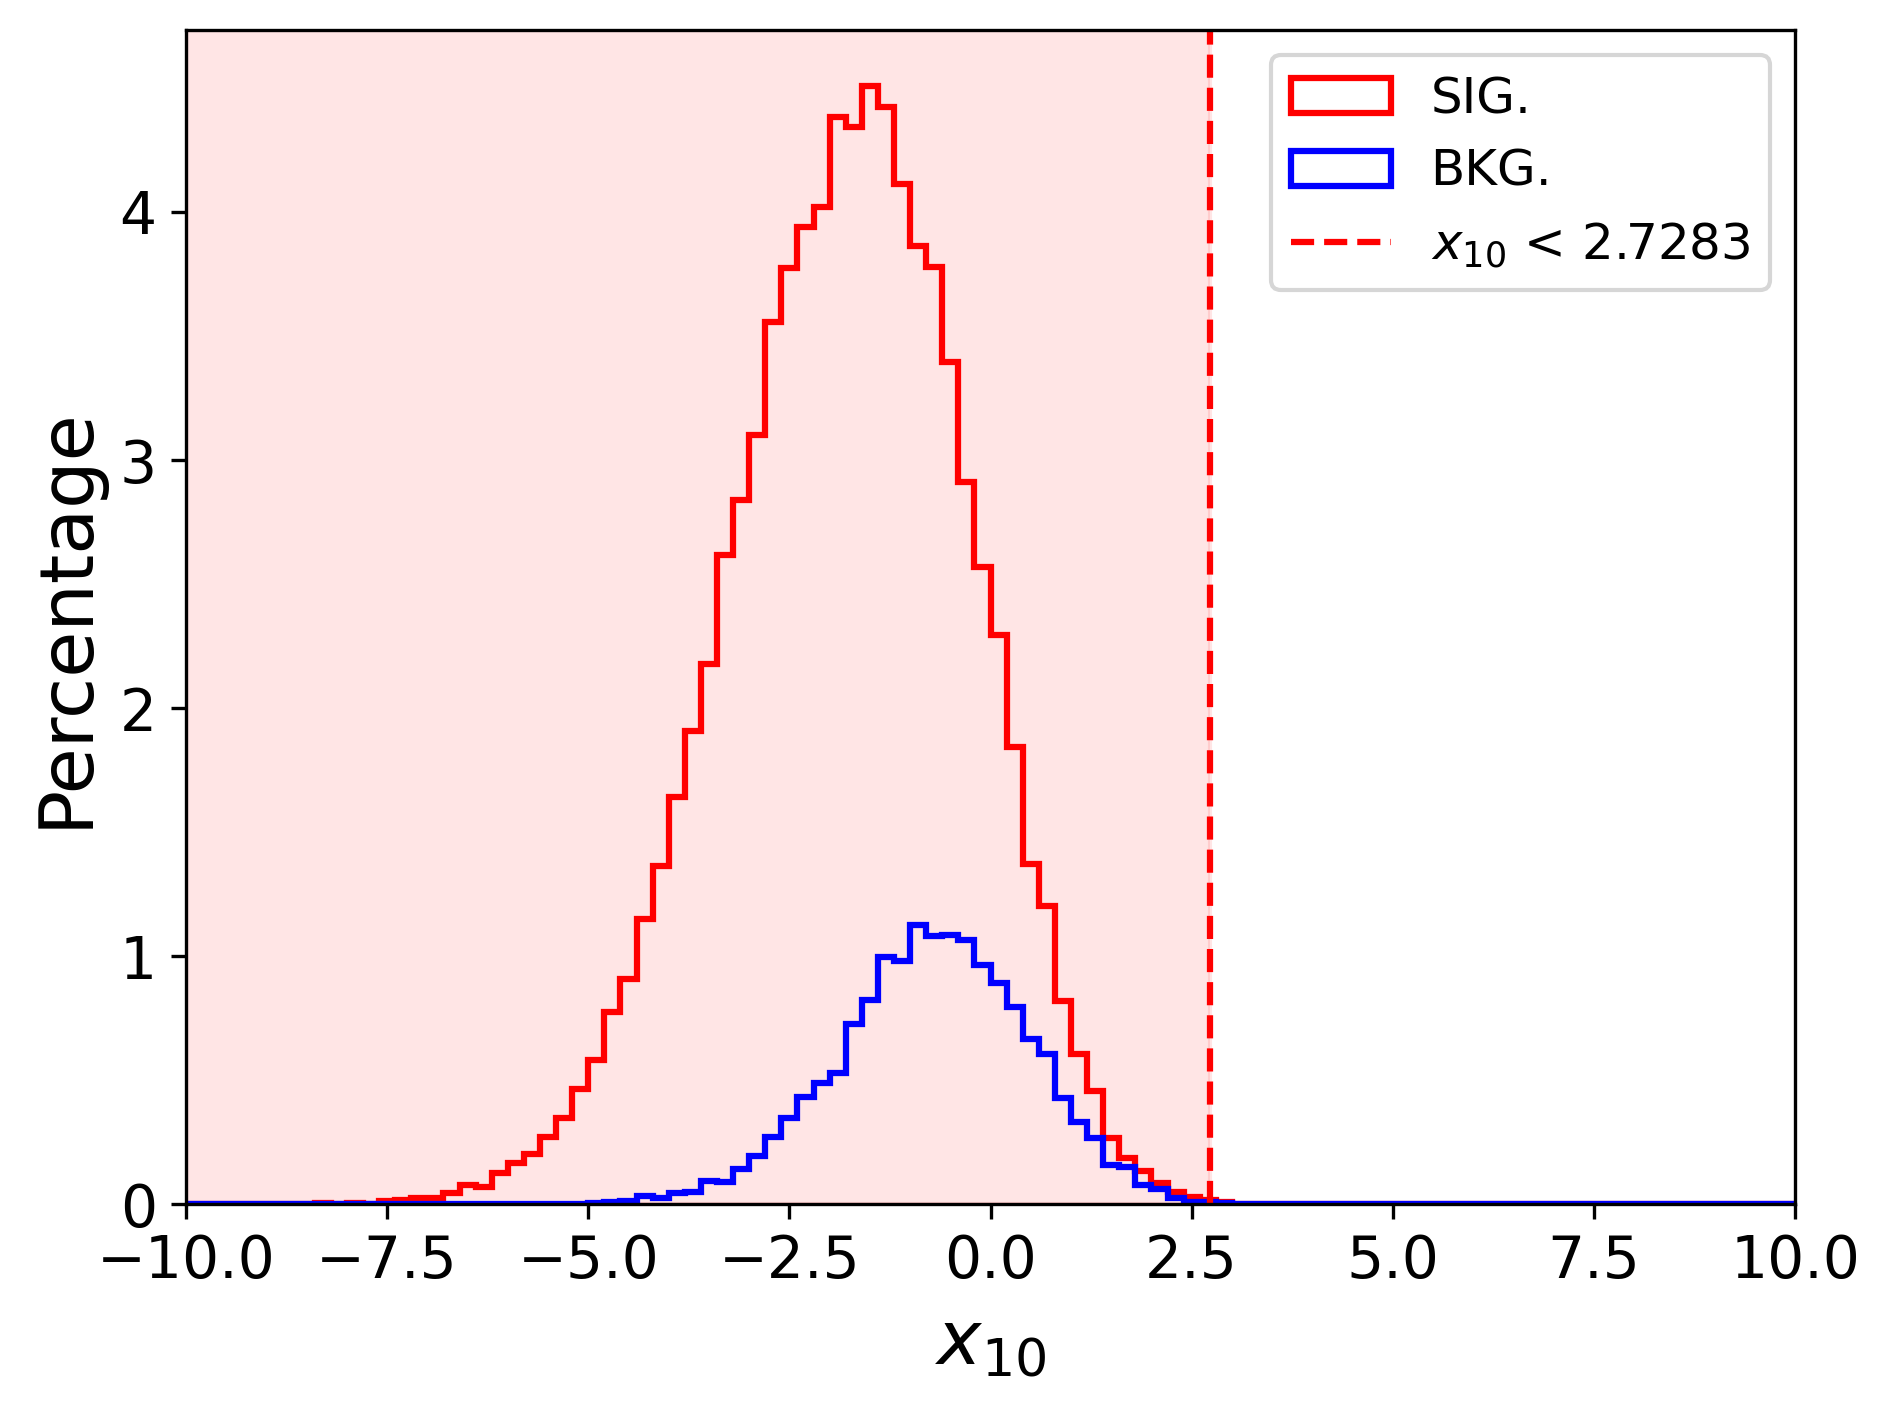

In [10]:
# Figure: learned cuts
features_str = [tex_to_str(feature) for feature in features]

df = pd.DataFrame(x_test, columns=features_str)
df["y"] = y_test.squeeze()

for i, feature in enumerate(features):
    sig = df.query("y == 1")[features_str[i]]
    bkg = df.query("y == 0")[features_str[i]]
    weights_sig = 100 * np.ones_like(sig) / len(df)
    weights_bkg = 100 * np.ones_like(bkg) / len(df)

    plot_learned_cut(
        case=checkpoint.cuts[i].case,
        index=checkpoint.cuts[i].index,
        boundaries=checkpoint.cuts[i].boundaries,
        expression=checkpoint.cuts[i].expression,
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )
    plot_learned_cut(
        case=checkpoint.cuts[i].case,
        index=checkpoint.cuts[i].index,
        boundaries=checkpoint.cuts[i].boundaries,
        expression=checkpoint.cuts[i].expression,
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"learned_cut-{tex_to_str(feature)}.pdf",
    )

    if isinstance(checkpoint, LearnableCutFlowSequentialModel):
        cut_query = checkpoint.cuts[i].expression.replace(
            features[i], f"`{features_str[i]}`"
        )
        df = df.query(cut_query)

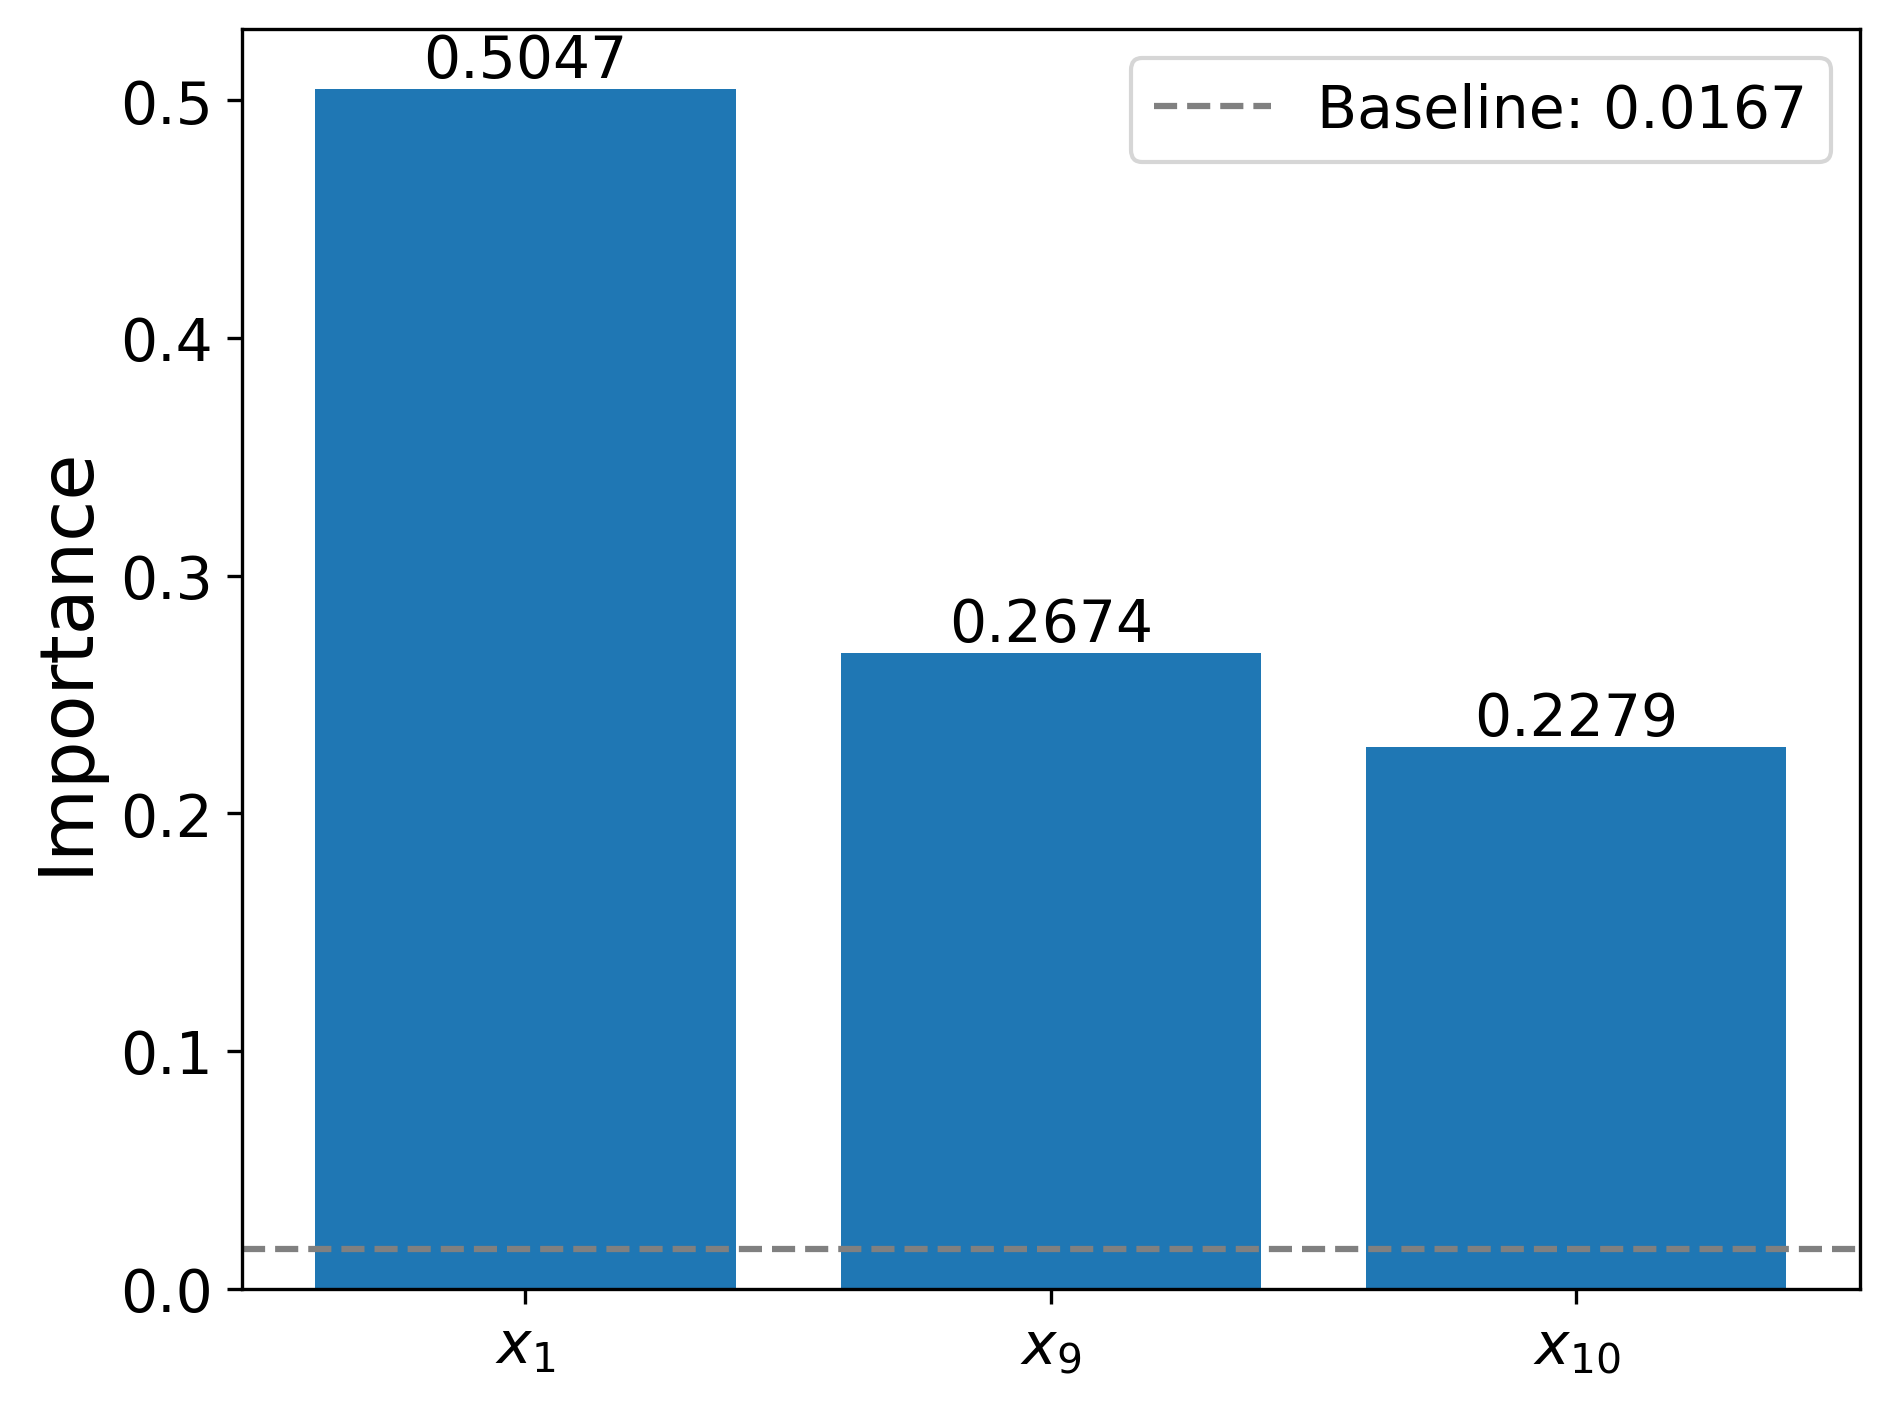

In [11]:
# Figure: learned importance
plot_learned_importance(
    scores=checkpoint.importance.scores,
    baseline=checkpoint.importance.baseline,
    features=features,
)
plot_learned_importance(
    scores=checkpoint.importance.scores,
    baseline=checkpoint.importance.baseline,
    features=features,
    to_file=FIGURES_DIR / "learned_importance.pdf",
)